In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import netCDF4
import numpy as np
import xarray as xr
#import pandas as pd 
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.util import add_cyclic_point
from windspharm.xarray import VectorWind
mpl.rcParams['mathtext.default'] = 'regular'
#import numpy as np
import cartopy.feature as feature

In [2]:
ds1=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/ENSO2/Regression_SST_spatial_pattern_ENSO2_ERSSTv5-23models.nc')
ds2=xr.open_dataset('/g/data/jk72/sm3719/cmip6/ESSD/regression/ENSO2/Regression_SST_spatial_pattern_ENSO2_MMM.nc')

CPENSO1=ds1['SLOPE'][0,:,:]
CPENSO2=ds1['SLOPE'][1,:,:]
CPENSO3=ds1['SLOPE'][2,:,:]
CPENSO4=ds1['SLOPE'][3,:,:]
CPENSO5=ds1['SLOPE'][4,:,:]
CPENSO6=ds1['SLOPE'][5,:,:]
CPENSO7=ds1['SLOPE'][6,:,:]
CPENSO8=ds1['SLOPE'][7,:,:]
CPENSO9=ds1['SLOPE'][8,:,:]
CPENSO10=ds1['SLOPE'][9,:,:]

print(ds1.coords)
#print(ds9)
#weight=ds9['clat']
#wslope1=slope1*weight
#weight.shape
print(ds1.coords)
LON = ds1.LON121_281.data
LAT = ds1.LAT60_121.data
LON=np.linspace(120,280,161)
LAT=np.linspace(-30,30,62)
LON,LAT=np.meshgrid(LON,LAT)

#LON1 = ds9.LON.data
#LAT1 = ds9.LAT.data
#LON1=np.linspace(40,110,36)
#LAT1=np.linspace(-20,25,23)
#LON1,LAT1=np.meshgrid(LON1,LAT1)


Coordinates:
  * time        (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON121_281  (LON121_281) float64 1kB 120.0 121.0 122.0 ... 278.0 279.0 280.0
  * LAT60_121   (LAT60_121) float64 496B -30.42 -29.42 -28.42 ... 29.42 30.42
Coordinates:
  * time        (time) float64 192B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
  * LON121_281  (LON121_281) float64 1kB 120.0 121.0 122.0 ... 278.0 279.0 280.0
  * LAT60_121   (LAT60_121) float64 496B -30.42 -29.42 -28.42 ... 29.42 30.42


In [3]:
print(CPENSO1.shape)

(62, 161)


In [4]:
CPENSO11=ds1['SLOPE'][10,:,:]
CPENSO12=ds1['SLOPE'][11,:,:]
CPENSO13=ds1['SLOPE'][12,:,:]
CPENSO14=ds1['SLOPE'][13,:,:]
CPENSO15=ds1['SLOPE'][14,:,:]
CPENSO16=ds1['SLOPE'][15,:,:]
CPENSO17=ds1['SLOPE'][16,:,:]
CPENSO18=ds1['SLOPE'][17,:,:]
CPENSO19=ds1['SLOPE'][18,:,:]
CPENSO20=ds1['SLOPE'][19,:,:]
CPENSO21=ds1['SLOPE'][20,:,:]
CPENSO22=ds1['SLOPE'][21,:,:]
CPENSO23=ds1['SLOPE'][22,:,:]
CPENSO24=ds1['SLOPE'][23,:,:]
CPENSO25=ds2['MMM'][:,:]

In [5]:
datasets = [
    (CPENSO1, "(a) ERSSTv5 (EOF2-8.1%)"),
    (CPENSO2, "(b) CanESM5 (EOF2-6.9%)"),
    (CPENSO3, "(c) HadGEM3-GC31-LL (EOF2-6.3%)"),
    (CPENSO4, "(d) EC-Earth3-CC (EOF2-6.4%)"),
    (CPENSO5, "(e) CMCC-CM2-SR5 (EOF2-5.3%)"),
    (CPENSO6, "(f) CNRM-CM6-1 (EOF2-4.9%)"),
    (CPENSO7, "(g) GISS-E2-1-G (EOF2-6.3%)"),
    (CPENSO8, "(h) CMCC-ESM2 (EOF2-5.3%)"),
    (CPENSO9, "(i) EC-Earth3 (EOF2-6.9%)"),
    (CPENSO10, "(j) E3SM1-0 (EOF2-9.6%)"),
    (CPENSO11, "(k) MIROC6 (EOF2-7.5%)"),
    (CPENSO12, "(l) MRI-ESM2-0 (EOF2-7.9%)"),
    (CPENSO13, "(m) HadGEM3-GC31-MM (EOF2-8.4%)"),
    (CPENSO14, "(n) BCC-CSM2-MR (EOF2-11.4%)"),
    (CPENSO15, "(o) IPSL-CM6A-LR (EOF2-8.4%)"),
    (CPENSO16, "(p) MPI-ESM1-2-HR (EOF2-5.5%)"),
    (CPENSO17, "(q) ACCESS-ESM1-5 (EOF2-14.0%)"),
    (CPENSO18, "(r) ACCESS-CM2 (EOF2-10.9%)"),
    (CPENSO19, "(s) CESM2 (EOF2-8.5%)"),
    (CPENSO20, "(t) GFDL-CM4 (EOF2-6.5%)"),
    (CPENSO21, "(u) CIESM (EOF2-7.6%)"),
    (CPENSO22, "(v) FGOALS-g3 (EOF2-9.5%)"),
    (CPENSO23, "(w) SAM0-UNICON (EOF2-8.2%)"),
    (CPENSO24, "(x) CNRM-ESM2-1 (EOF2-6.9%)"),
    (CPENSO25, "(y) MMM")
]

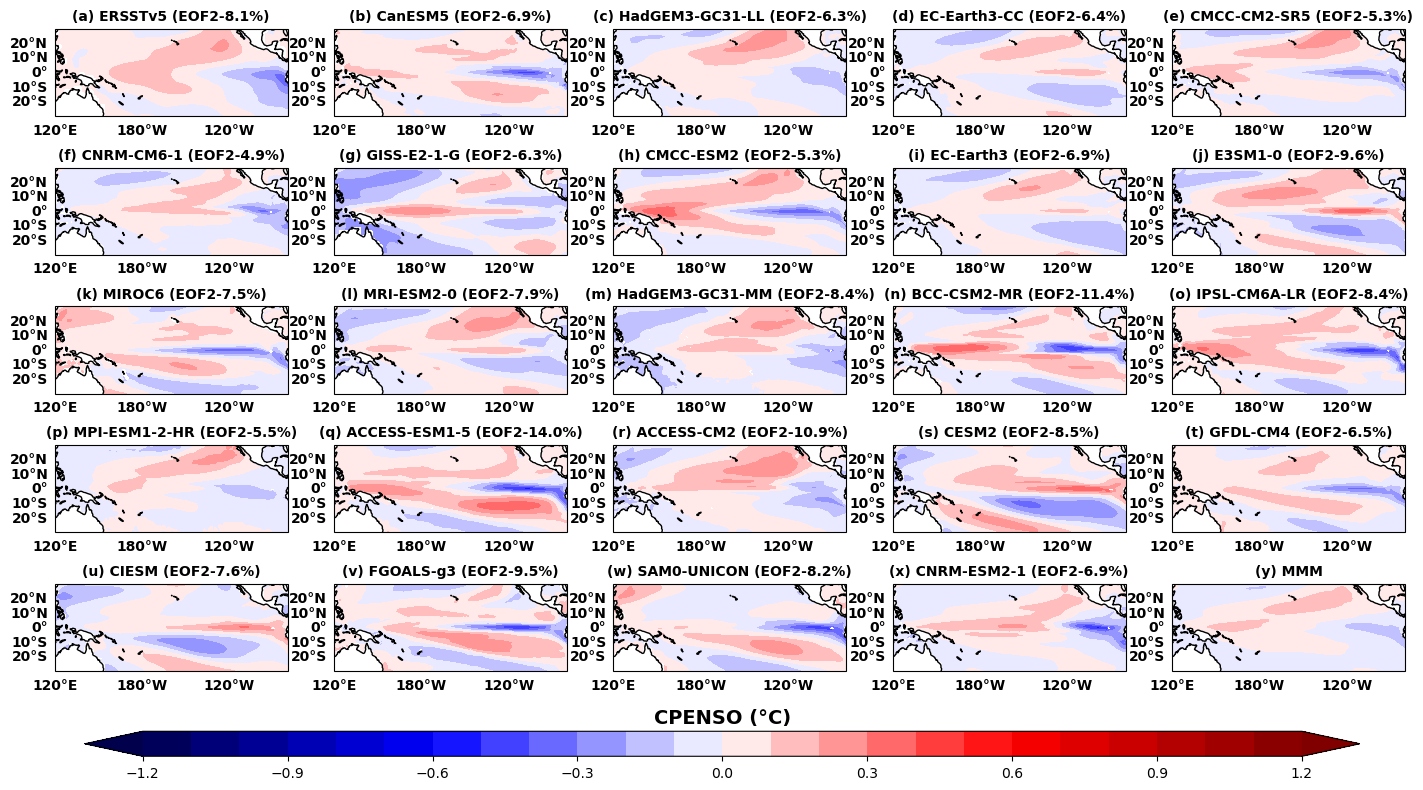

In [7]:
# Subplot configuration
nrows, ncols = 5, 5
start_index = 1  # Starting index for subplots
projection = ccrs.PlateCarree(central_longitude=260)
clevs = np.arange(-1.2,1.3,0.1)

# Create figure
fig = plt.figure(figsize=(15, 12.5))
# Store the last `contourf` plot for the colorbar
last_fill_sf = None

for i, (data, title) in enumerate(datasets, start=start_index):
    ax = plt.subplot(nrows, ncols, i, projection=projection)
    fill_sf = ax.contourf(LON, LAT, data, levels=clevs, cmap=plt.cm.seismic, transform=ccrs.PlateCarree(), extend='both')
    last_fill_sf = fill_sf  # Update the last contourf object
    ax.set_aspect('equal')
    ax.coastlines()
    ax.set_title(title, fontsize=10, loc='center', color='black', fontweight='bold')
#    ax.annotate(annotation, xy=(0.5, -0.15), xycoords='axes fraction', ha='center', va='top', fontsize=10, color='red', fontweight='bold')
    # Gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
# --- Longitude labels ---
    gl.top_labels = False       # no longitude labels on top
    gl.bottom_labels = True     # show longitude labels only on the bottom
# --- Latitude labels ---
    gl.left_labels = True       # keep latitude labels on the left
    gl.right_labels = False     # no latitude labels on the right
# --- Gridline drawing ---
    gl.xlines = False           # don't draw the longitude gridlines themselves
    gl.ylines = False           # don't draw the latitude gridlines themselves
# --- Formatters ---
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Adjust layout (moved outside the `if` block)
plt.subplots_adjust(bottom=0.4, left=0.08, right=0.98, top=0.95, hspace=0.05)

# Add colorbar
if last_fill_sf is not None:  # Check if a valid contourf object exists
    cax = plt.axes([0.1, 0.35, 0.85, 0.02])  # Adjust these values for proper placement
    clb = plt.colorbar(last_fill_sf, cax=cax, orientation='horizontal', fraction=0.1, pad=0.05)
    clb.ax.set_title('CPENSO (°C)', loc='center', color='black', fontsize=14, fontweight='bold')

# Save and show plot
plt.savefig('/g/data/jk72/sm3719/cmip6/ESSD/climate_mode/panel25_regression_ENSO2_observations_models_mmm.png', dpi=600)
plt.show()